 # Customer Churn Prediction — Exploratory Data Analysis

**Objective:** Understand which customers are likely to churn from property/telecom-style features.  
**Target variable:** `churn` (`Yes` / `No`)  
**Context:** Messy customer data loaded from CSV for practicing a full EDA workflow end to end (same step pattern as the house-price EDA session).

### How to use this notebook
Work top to bottom. Each numbered step has:
1. A short **why** (purpose of the step)
2. Code that performs the step (fill every `# TODO` cell)
3. Space for insights at the end

| Step | Focus |
|------|--------|
| 1–2 | Load / inspect |
| 3–5 | Missing values, duplicates, dtypes |
| 6–7 | Summaries & outliers |
| 8 | Binning (after outliers) |
| 9–11 | Uni / bi / multivariate visuals |
| 12 | Key findings (markdown) |

**Dataset file:** `customer_churn.csv` (same folder as this notebook).

**Required names for grading:** `df`, `raw_shape`, `missing_df`, `num_cols_with_na`, `cat_cols_with_na`, `df_before_outliers`, `outliers_iqr_mask`, `age_bin`, `corr_matrix`, `multi_corr`, `top_corr_with_churn`

# **Important**:Make sure you use the same variable name mentioned above

## 0. Imports

Import numpy, pandas, matplotlib, seaborn, and display helpers.

In [3]:
# TODO: Write your solution here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


## 1. Load Dataset

### Why this step
EDA starts with data on disk. Load `customer_churn.csv` so the rest of the notebook mirrors a real workflow: read a file, then clean and plot.

### What the code does
1. Reads the CSV with `pd.read_csv` into **`df`**.
2. Prints shape and column names, then shows the first few rows.

In [4]:
# TODO: Write your solution here.
df = pd.read_csv("customer_churn.csv")
print("Shape: ",df.shape)
print("Columns: ",df.columns.tolist())
df.head()

Shape:  (518, 12)
Columns:  ['customer_id', 'age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets', 'contract_type', 'internet_service', 'payment_method', 'gender', 'partner', 'churn']


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No


## 2. Inspect the Data

### Why this step
Never clean or model blind. First look at samples and types so you know what each column is and whether missing values already appear.

### What the code does
- `head()` / `tail()`: first and last rows
- `dtypes`: int / float / object
- `info()`: non-null counts and memory

In [5]:
# TODO: Write your solution here.
print("First 5 rows")
display(df.head())
print("\n Last 5 rows")
display(df.tail())
print("\n Data Types")
print(df.dtypes)
print("\n Dataset information")
df.info()

First 5 rows


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No



 Last 5 rows


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
513,C10084,79.0,45,NaN,1324.55,5,Month-to-month,DSL,Electronic check,Female,Yes,Yes
514,C10371,36.0,48,67.95,3486.47,2,Two year,DSL,Mailed check,Male,No,No
515,C10388,44.0,65,96.92,5779.48,6,Month-to-month,Fiber optic,Credit card,Male,Yes,No
516,C10495,52.0,30,67.93,1787.24,7,Month-to-month,DSL,Credit card,Female,Yes,Yes
517,C10030,46.0,32,22.43,765.80,4,One year,DSL,Bank transfer,Female,Yes,No



 Data Types
customer_id                str
age                    float64
tenure_months            int64
monthly_charges        float64
total_charges          float64
num_support_tickets      int64
contract_type              str
internet_service           str
payment_method             str
gender                     str
partner                    str
churn                      str
dtype: object

 Dataset information


<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          518 non-null    str    
 1   age                  489 non-null    float64
 2   tenure_months        518 non-null    int64  
 3   monthly_charges      494 non-null    float64
 4   total_charges        498 non-null    float64
 5   num_support_tickets  518 non-null    int64  
 6   contract_type        502 non-null    str    
 7   internet_service     504 non-null    str    
 8   payment_method       518 non-null    str    
 9   gender               518 non-null    str    
 10  partner              518 non-null    str    
 11  churn                518 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 48.7 KB


## 3. Handle Missing Values

### Why this step
Models and many aggregations fail or become biased when NaNs remain. Find gaps first, then choose a fill strategy that matches each column type.

### 3a. Count nulls
Create **`missing_df`** with columns `Missing` and `Percent`, filtered to columns that have nulls, sorted descending.

In [6]:
# TODO: Write your solution here.
missing_df = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Percent": df.isnull().mean()*100
})
missing_df = missing_df[missing_df["Missing"]>0]
missing_df = missing_df.sort_values("Missing",ascending=False)
missing_df


,Missing,Percent
age,29,5.598456
monthly_charges,24,4.633205
total_charges,20,3.861004
contract_type,16,3.088803
internet_service,14,2.702703


### 3b. Inspect numeric missing values (skew → mean vs median)

For skewed numerics prefer **median**; for roughly symmetric prefer **mean**.

Print **`num_cols_with_na`** and **`cat_cols_with_na`**.  
Plot a histogram for a skewed numeric column with nulls (e.g. `monthly_charges`) and print mean / median / mode.

Numeric columns with missing values: 
['age', 'monthly_charges', 'total_charges']

 Categorical columns with missing values: 
['contract_type', 'internet_service']
\Column: age
Mean:  47.75255623721881
Median:  47.0
Mode:  27.0
\Column: monthly_charges
Mean:  80.31449392712551
Median:  70.565
Mode:  450.0
\Column: total_charges
Mean:  2991.5734939759036
Median:  1981.05
Mode:  218.78


<>:9: SyntaxWarning: invalid escape sequence '\C'
<>:9: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_48958/1083136295.py:9: SyntaxWarning: invalid escape sequence '\C'
  print(f"\Column: {col}")


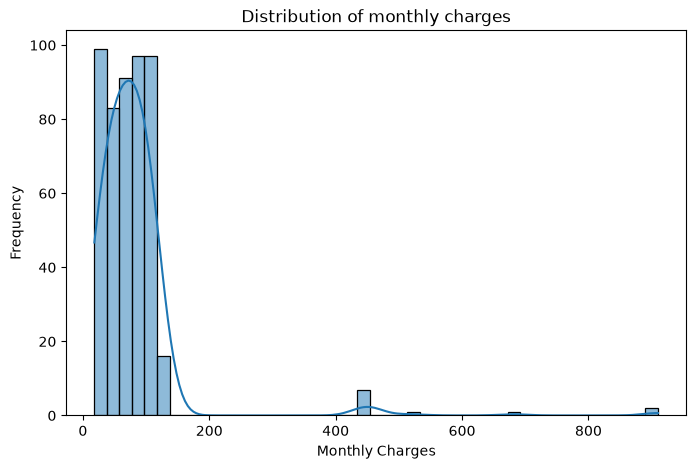

In [10]:
# TODO: Write your solution here.
nums_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isna().any()].tolist()
cat_cols_with_na = df.select_dtypes(exclude=np.number).columns[df.select_dtypes(exclude=np.number).isna().any()].tolist()
print("Numeric columns with missing values: ")
print(nums_cols_with_na)
print("\n Categorical columns with missing values: ")
print(cat_cols_with_na)
for col in nums_cols_with_na:
    print(f"\Column: {col}")
    print("Mean: ",df[col].mean())
    print("Median: ",df[col].median())
    print("Mode: ",df[col].mode().iloc[0])

if "monthly_charges" in nums_cols_with_na:
    plt.figure(figsize=(8,5))
    sns.histplot(df["monthly_charges"].dropna(),kde=True)
    plt.title("Distribution of monthly charges")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Frequency")
    plt.show()



### 3c. Inspect categorical missing values

For each categorical column with nulls, print the **mode** and **unique values**.

In [13]:
# TODO: Write your solution here.
for col in cat_cols_with_na:
    print(f"\nColumn: {col}")
    print("Mode:", df[col].mode().iloc[0])
    print("Unique Values:",df[col].dropna().unique())



Column: contract_type
Mode: Month-to-month
Unique Values: <StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

Column: internet_service
Mode: Fiber optic
Unique Values: <StringArray>
['Fiber optic', 'No', 'DSL']
Length: 3, dtype: str


### 3d. Fill missing values

Fill in place on **`df`**:
- Numeric: **median** when `|skew| > 0.5`, else **mean**
- Categorical: **mode**
- Any leftover numeric NaNs: `ffill` then `bfill`
- Verify remaining missing count is **0**

In [14]:
# TODO: Write your solution here.
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().any():
        if abs(df[col].skew()) > 0.5:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())
for col in df.select_dtypes(exclude=np.number).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])
df = df.ffill().bfill()
print("Total remaining missing values:",df.isna().sum().sum())

Total remaining missing values: 0


## 4. Duplicate Records

### Why this step
Exact duplicate rows overweight the same customer in averages, correlations, and model training.

### What the code does
Count duplicates with `duplicated()`, then remove them with `drop_duplicates()` and reset the index.

In [15]:
# TODO: Write your solution here.
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)
df = df.drop_duplicates().reset_index(drop=True)
print("New Shape:", df.shape)

Duplicate Rows: 14
New Shape: (504, 12)


### Check remaining nulls

Re-check before type casting. If any null rows remain, drop them.

In [16]:
# TODO: Write your solution here.
print("Missing values in each column:")
print(df.isnull().sum())
if df.isnull().sum().sum()>0:
    df = df.dropna().rest_index(drop=True)
print("\n Total remaining null values: ",df.isnull().sum().sum())

Missing values in each column:
customer_id            0
age                    0
tenure_months          0
monthly_charges        0
total_charges          0
num_support_tickets    0
contract_type          0
internet_service       0
payment_method         0
gender                 0
partner                0
churn                  0
dtype: int64

 Total remaining null values:  0


## 5. Convert Data Types

### Why this step
Correct types unlock groupbys and integer summaries. Wrong types (e.g. labels as plain object only) make analysis harder.

### What the code does
- Cast label columns to `category`
- Cast whole-number-ish numerics to int where safe
- Create **`churn_flag`** (Yes→1, No→0) for later correlation

Binning comes **after** outlier handling (Step 8).

In [18]:
# TODO: Write your solution here.
label_cols = df.select_dtypes(include="object").columns.tolist()
for col in label_cols:
    df[col] = df[col].astype("category")
for col in df.select_dtypes(include=np.number).columns:
    if col != "churn_flag":
        if df[col].notna().all() and (df[col]%1==0).all():
            df[col]= df[col].astype(int)
df["churn_flag"] = df["churn"].map({"Yes":1,"No":0}).astype(int)
print(df.dtypes)
df.head()

/tmp/ipykernel_48958/3631502802.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  label_cols = df.select_dtypes(include="object").columns.tolist()


customer_id            category
age                       int64
tenure_months             int64
monthly_charges         float64
total_charges           float64
num_support_tickets       int64
contract_type          category
internet_service       category
payment_method         category
gender                 category
partner                category
churn                  category
churn_flag                int64
dtype: object


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn,churn_flag
0,C10000,19,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes,1
1,C10001,27,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No,0
2,C10002,24,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No,0
3,C10003,24,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No,0
4,C10004,56,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No,0


## 6. Summary Statistics

### Why this step
Summaries describe center, spread, and range before plotting. Large mean–median gaps hint at skew.

### What the code does
- `describe()` for numerics
- Mean / median / mode table for skewed columns
- Value counts for key categoricals

In [20]:
# TODO: Write your solution here.
display(df.describe())
num_cols = df.select_dtypes(include=np.number).columns
summary_stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0]
})
display(summary_stats)
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"\nValue Counts for {col}")
    print(df[col].value_counts())

,age,tenure_months,monthly_charges,total_charges,num_support_tickets,churn_flag
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,47.952381,36.027778,79.969643,2969.139187,3.436508,0.468254
std,18.134184,20.928336,82.017886,4090.641796,2.292684,0.499487
min,18.000000,0.000000,18.130000,25.680000,0.000000,0.000000
25%,32.000000,19.000000,45.620000,955.105000,1.000000,0.000000
50%,47.500000,36.000000,70.565000,1981.050000,3.000000,0.000000
75%,63.250000,54.250000,97.332500,3712.190000,5.000000,1.000000
max,79.000000,72.000000,910.000000,51511.120000,7.000000,1.000000


,Mean,Median,Mode
age,47.952381,47.500,27.00
tenure_months,36.027778,36.000,6.00
monthly_charges,79.969643,70.565,450.00
total_charges,2969.139187,1981.050,3125.24
num_support_tickets,3.436508,3.000,2.00
churn_flag,0.468254,0.000,0.00



Value Counts for customer_id
customer_id
C10009    2
C10084    2
C10194    2
C10361    2
C10000    1
         ..
C10495    1
C10496    1
C10497    1
C10498    1
C10499    1
Name: count, Length: 500, dtype: int64

Value Counts for contract_type
contract_type
Month-to-month    303
One year          107
Two year           94
Name: count, dtype: int64

Value Counts for internet_service
internet_service
Fiber optic    240
DSL            161
No             103
Name: count, dtype: int64

Value Counts for payment_method
payment_method
Bank transfer       136
Electronic check    134
Credit card         117
Mailed check        117
Name: count, dtype: int64

Value Counts for gender
gender
Female    281
Male      223
Name: count, dtype: int64

Value Counts for partner
partner
No     272
Yes    232
Name: count, dtype: int64

Value Counts for churn
churn
No     268
Yes    236
Name: count, dtype: int64


## 7. Detect Outliers (IQR & Z-score)

### Why this step
Extreme `monthly_charges` can distort means and correlations. Detect candidates, then **cap (winsorize)** like the house-price notebook (keep rows, reduce extreme pull).

### What the code does
1. Save **`df_before_outliers`**
2. Box plots + IQR / Z-score counts
3. Build **`outliers_iqr_mask`** for `monthly_charges`
4. Cap `monthly_charges` (and `total_charges`) at IQR fences

ModuleNotFoundError: No module named 'scipy'

## 8. Binning

### Why this step
After outliers are handled, turn continuous fields into interpretable categories for group analysis (same idea as engineered features in the house-price EDA session).

### What the code does
Create **`age_bin`** and `tenure_bin`, then show value counts.

In [ ]:
# TODO: Write your solution here.


## 9. Univariate Analysis

### Why this step
Study **one variable at a time** first — shape, typical ranges, and category balance — before relating variables to each other.

In [ ]:
# TODO: Write your solution here.


## 10. Bivariate Analysis

### Why this step
Bivariate = relationship between **two** variables — where you find predictors of `churn`.

Split by types:
- **Numerical vs Numerical** — scatter / correlation
- **Numerical vs Categorical** — box / violin / bar
- **Categorical vs Categorical** — crosstab / stacked bar / heatmap

### Numerical vs Numerical

Scatter plots and Pearson correlation with `churn_flag`.

In [ ]:
# TODO: Write your solution here.


### Numerical vs Categorical

Compare charges / tenure across churn and contract groups.

In [ ]:
# TODO: Write your solution here.


### Categorical vs Categorical

Crosstabs, stacked bars, and heatmaps for category mixes vs churn.

In [ ]:
# TODO: Write your solution here.


## 11. Multivariate Analysis

### Why this step
Look at **three or more** signals together — closer to how churn really works (tenure + charges + tickets, etc.).

1. **Heatmap** — many numeric correlations at once (`multi_corr`)
2. **Bubble chart** — scatter with size + color

In [ ]:
# TODO: Write your solution here.


## 12. KEY FINDINGS — answer in markdown

This is the **final step**. Write 2–4 sentences for each question based on what you observed above.

### Q1. Which numeric features are most correlated with `churn_flag`? What does that imply?
### Q2. After the skew check, did you prefer mean or median for any fills? Why?
### Q3. Which segments (contract, age bin, tickets) look most associated with churn?
### Q4. Why cap outliers instead of deleting rows here?
### Q5. What risk remains before training a churn classifier?

### Your answers

**Q1:** _(write here)_

**Q2:** _(write here)_

**Q3:** _(write here)_

**Q4:** _(write here)_

**Q5:** _(write here)_
